# EDA — Limpieza y validación de datos
=======
Datasets:
  - songs_rows.csv  → canciones con metadata
  - lyrics_rows.csv → letras asociadas a canciones

Pasos:
  1. Carga de datos
  2. Limpieza: eliminar canciones que no estén en español
  3. Deduplicación: canciones repetidas y letras repetidas
  4. Merge de ambos datasets
  5. Reporte de calidad del dataset final


═══════════════════════════════════════════════════════
  1. CARGA DE DATOS
═══════════════════════════════════════════════════════

📀 songs_rows.csv  →  1686 filas | 17 columnas
📝 lyrics_rows.csv →  1455 filas | 10 columnas

── Columnas songs ──
id                    int64
created_at           object
ranking_position    float64
title                object
artist               object
streams             float64
genre                object
lyrics              float64
album                object
year                float64
duration_seg        float64
language_variant     object
source               object
url_source           object
extra_data           object
lyrics_status        object
artist_gender       float64
dtype: object

── Columnas lyrics ──
id                     int64
song_id                int64
lyrics_text           object
lyrics_hash           object
word_count             int64
verse_count            int64
language_detected     object
source                object
lyrics_

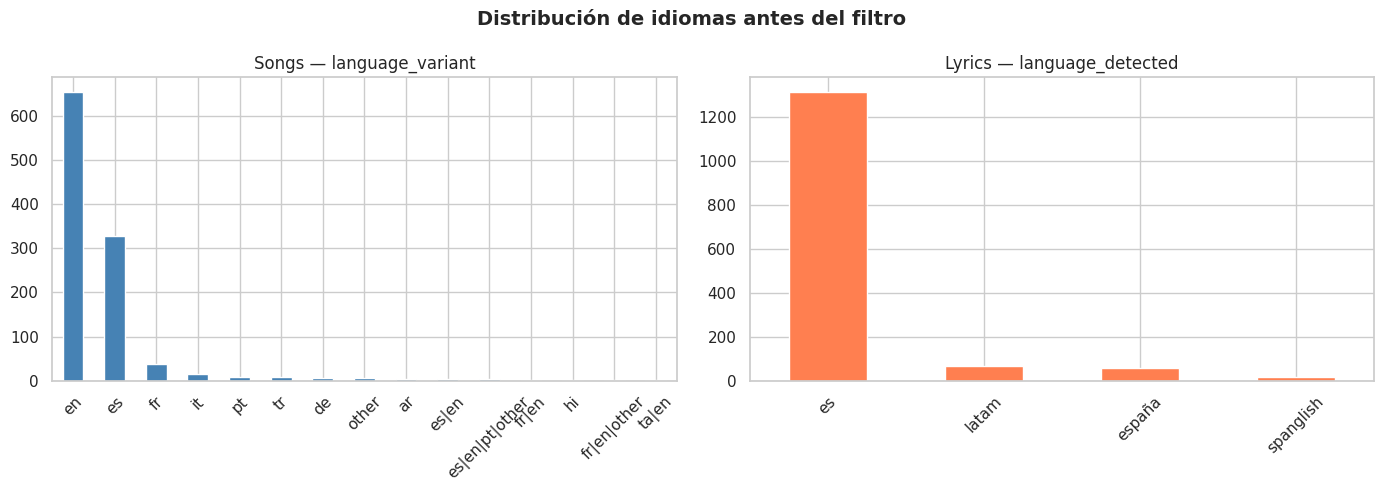

   📊 Guardado: plot_01_idiomas.png

═══════════════════════════════════════════════════════
  3. DEDUPLICACIÓN
═══════════════════════════════════════════════════════

🔁 Canciones duplicadas (mismo título + artista): 0
   ✔ songs  : 327 → 327 filas (−0 dupes)

🔁 Letras con hash duplicado (letra idéntica): 0
   ✔ lyrics (hash): 1313 → 1313 filas (−0 dupes)

🔁 Letras con song_id duplicado (misma canción): 0
   ✔ lyrics (song_id): 1313 → 1313 filas (−0 dupes)


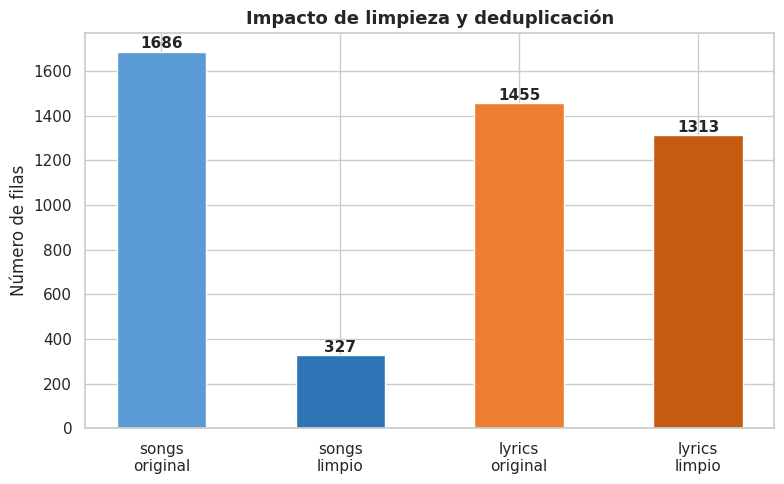

   📊 Guardado: plot_02_deduplicacion.png

═══════════════════════════════════════════════════════
  4. MERGE songs + lyrics
═══════════════════════════════════════════════════════

✅ Dataset combinado: 199 filas | 27 columnas
⚠️  Canciones sin letra asociada : 128
⚠️  Letras sin canción asociada  : 1114

   Canciones sin letra (primeras 10):
 id                  title              artist
  1 en la granja de mi tio             heykids
  2           duermetenino       musicanocheto
  4             la lechuza el payaso plim plim
 11                   dtmf           bad bunny
 13                    eoo           bad bunny
 16                  velda           bad bunny
 32                 monaco           bad bunny
 55          si te pillara               beele
 67            video phone        selena mezgo
 78        yogurcito remix              blessd

═══════════════════════════════════════════════════════
  5. REPORTE DE CALIDAD
═══════════════════════════════════════════════════════

┌

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ──────────────────────────────────────────────
# CONFIGURACIÓN
# ──────────────────────────────────────────────

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

SONGS_PATH  = "songs_rows.csv"
LYRICS_PATH = "lyrics_rows.csv"


# ══════════════════════════════════════════════
# 1. CARGA DE DATOS
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  1. CARGA DE DATOS")
print("═"*55)

df_songs  = pd.read_csv(SONGS_PATH)
df_lyrics = pd.read_csv(LYRICS_PATH)

print(f"\n📀 songs_rows.csv  → {df_songs.shape[0]:>5} filas | {df_songs.shape[1]} columnas")
print(f"📝 lyrics_rows.csv → {df_lyrics.shape[0]:>5} filas | {df_lyrics.shape[1]} columnas")

print("\n── Columnas songs ──")
print(df_songs.dtypes)

print("\n── Columnas lyrics ──")
print(df_lyrics.dtypes)

print("\n── Nulos songs ──")
print(df_songs.isnull().sum()[df_songs.isnull().sum() > 0])

print("\n── Nulos lyrics ──")
print(df_lyrics.isnull().sum()[df_lyrics.isnull().sum() > 0])


# ══════════════════════════════════════════════
# 2. LIMPIEZA — FILTRO DE IDIOMA ESPAÑOL
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  2. LIMPIEZA — FILTRO IDIOMA ESPAÑOL")
print("═"*55)

songs_inicial  = len(df_songs)
lyrics_inicial = len(df_lyrics)

# ── 2a. Filtrar songs por language_variant ─────
# Valores esperados en español: 'es', 'es-ES', 'es-MX', 'es-AR', etc.
VARIANTES_ES = ["es", "es-es", "es-mx", "es-ar", "es-co", "es-py", "es-us", "espanol", "español", "spanish"]

if "language_variant" in df_songs.columns:
    df_songs["_lang_norm"] = df_songs["language_variant"].astype(str).str.lower().str.strip()
    mask_songs_es = df_songs["_lang_norm"].isin(VARIANTES_ES)
    songs_no_es   = df_songs[~mask_songs_es][["id", "title", "artist", "language_variant"]]

    print(f"\n🔍 Canciones con language_variant no español: {len(songs_no_es)}")
    if len(songs_no_es) > 0:
        print(songs_no_es.to_string(index=False))

    df_songs = df_songs[mask_songs_es].drop(columns=["_lang_norm"]).reset_index(drop=True)
    print(f"   ✔ songs  : {songs_inicial} → {len(df_songs)} filas (−{songs_inicial - len(df_songs)})")
else:
    print("   ⚠️  'language_variant' no encontrada en songs, saltando filtro")

# ── 2b. Filtrar lyrics por language_detected ───
if "language_detected" in df_lyrics.columns:
    df_lyrics["_lang_norm"] = df_lyrics["language_detected"].astype(str).str.lower().str.strip()
    mask_lyrics_es = df_lyrics["_lang_norm"].isin(VARIANTES_ES)
    lyrics_no_es   = df_lyrics[~mask_lyrics_es][["id", "song_id", "language_detected"]]

    print(f"\n🔍 Letras con language_detected no español: {len(lyrics_no_es)}")
    if len(lyrics_no_es) > 0:
        print(lyrics_no_es.to_string(index=False))

    df_lyrics = df_lyrics[mask_lyrics_es].drop(columns=["_lang_norm"]).reset_index(drop=True)
    print(f"   ✔ lyrics : {lyrics_inicial} → {len(df_lyrics)} filas (−{lyrics_inicial - len(df_lyrics)})")
else:
    print("   ⚠️  'language_detected' no encontrada en lyrics, saltando filtro")

# ── 2c. Gráfico: distribución de idiomas antes del filtro ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de idiomas antes del filtro", fontsize=14, fontweight="bold")

if "language_variant" in pd.read_csv(SONGS_PATH).columns:
    pd.read_csv(SONGS_PATH)["language_variant"].value_counts().head(15).plot(
        kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
    )
    axes[0].set_title("Songs — language_variant")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=45)

if "language_detected" in pd.read_csv(LYRICS_PATH).columns:
    pd.read_csv(LYRICS_PATH)["language_detected"].value_counts().head(15).plot(
        kind="bar", ax=axes[1], color="coral", edgecolor="white"
    )
    axes[1].set_title("Lyrics — language_detected")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plot_01_idiomas.png", dpi=150, bbox_inches="tight")
plt.show()
print("   📊 Guardado: plot_01_idiomas.png")


# ══════════════════════════════════════════════
# 3. DEDUPLICACIÓN
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  3. DEDUPLICACIÓN")
print("═"*55)

# ── 3a. Canciones duplicadas en songs ──────────
# Duplicado = mismo título + artista (ignorando mayúsculas/espacios)
df_songs["_title_norm"]  = df_songs["title"].astype(str).str.lower().str.strip()
df_songs["_artist_norm"] = df_songs["artist"].astype(str).str.lower().str.strip()

dupes_songs = df_songs[df_songs.duplicated(subset=["_title_norm", "_artist_norm"], keep=False)]
print(f"\n🔁 Canciones duplicadas (mismo título + artista): {len(dupes_songs)}")
if len(dupes_songs) > 0:
    print(dupes_songs[["id", "title", "artist"]].sort_values("title").to_string(index=False))

songs_antes = len(df_songs)
df_songs = (
    df_songs
    .sort_values("created_at")                                        # conservamos el más antiguo
    .drop_duplicates(subset=["_title_norm", "_artist_norm"], keep="first")
    .drop(columns=["_title_norm", "_artist_norm"])
    .reset_index(drop=True)
)
print(f"   ✔ songs  : {songs_antes} → {len(df_songs)} filas (−{songs_antes - len(df_songs)} dupes)")

# ── 3b. Letras duplicadas por lyrics_hash ──────
# lyrics_hash es el SHA256 de la letra limpia → duplicado exacto
if "lyrics_hash" in df_lyrics.columns:
    dupes_hash = df_lyrics[df_lyrics.duplicated(subset=["lyrics_hash"], keep=False)]
    print(f"\n🔁 Letras con hash duplicado (letra idéntica): {len(dupes_hash)}")
    if len(dupes_hash) > 0:
        print(dupes_hash[["id", "song_id", "lyrics_hash"]].to_string(index=False))

    lyrics_antes = len(df_lyrics)
    df_lyrics = (
        df_lyrics
        .sort_values("created_at")
        .drop_duplicates(subset=["lyrics_hash"], keep="first")
        .reset_index(drop=True)
    )
    print(f"   ✔ lyrics (hash): {lyrics_antes} → {len(df_lyrics)} filas (−{lyrics_antes - len(df_lyrics)} dupes)")

# ── 3c. Letras duplicadas por song_id ──────────
# Una canción no debería tener más de una letra
dupes_song_id = df_lyrics[df_lyrics.duplicated(subset=["song_id"], keep=False)]
print(f"\n🔁 Letras con song_id duplicado (misma canción): {len(dupes_song_id)}")
if len(dupes_song_id) > 0:
    print(dupes_song_id[["id", "song_id", "word_count"]].to_string(index=False))

lyrics_antes = len(df_lyrics)
df_lyrics = (
    df_lyrics
    .sort_values("word_count", ascending=False)   # conservamos la letra con más palabras
    .drop_duplicates(subset=["song_id"], keep="first")
    .reset_index(drop=True)
)
print(f"   ✔ lyrics (song_id): {lyrics_antes} → {len(df_lyrics)} filas (−{lyrics_antes - len(df_lyrics)} dupes)")

# ── 3d. Gráfico: impacto de la deduplicación ───
fig, ax = plt.subplots(figsize=(8, 5))
categorias = ["songs\noriginal", "songs\nlimpio", "lyrics\noriginal", "lyrics\nlimpio"]
valores    = [songs_inicial, len(df_songs), lyrics_inicial, len(df_lyrics)]
colores    = ["#5b9bd5", "#2e75b6", "#ed7d31", "#c55a11"]
bars = ax.bar(categorias, valores, color=colores, edgecolor="white", width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Impacto de limpieza y deduplicación", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de filas")
plt.tight_layout()
plt.savefig("plot_02_deduplicacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("   📊 Guardado: plot_02_deduplicacion.png")


# ══════════════════════════════════════════════
# 4. MERGE DE AMBOS DATASETS
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  4. MERGE songs + lyrics")
print("═"*55)

# JOIN: songs.id = lyrics.song_id
df = pd.merge(
    df_songs,
    df_lyrics,
    left_on="id",
    right_on="song_id",
    how="inner",
    suffixes=("_song", "_lyric")
)

print(f"\n✅ Dataset combinado: {len(df)} filas | {df.shape[1]} columnas")

# Canciones sin letra
songs_sin_letra = set(df_songs["id"]) - set(df_lyrics["song_id"])
print(f"⚠️  Canciones sin letra asociada : {len(songs_sin_letra)}")

# Letras sin canción (huérfanas)
letras_sin_cancion = set(df_lyrics["song_id"]) - set(df_songs["id"])
print(f"⚠️  Letras sin canción asociada  : {len(letras_sin_cancion)}")

if len(songs_sin_letra) > 0:
    print("\n   Canciones sin letra (primeras 10):")
    print(df_songs[df_songs["id"].isin(songs_sin_letra)][["id", "title", "artist"]].head(10).to_string(index=False))


# ══════════════════════════════════════════════
# 5. REPORTE DE CALIDAD FINAL
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  5. REPORTE DE CALIDAD")
print("═"*55)

print(f"""
┌─────────────────────────────────────────────┐
│  RESUMEN DE LIMPIEZA                        │
├──────────────────────────┬──────────────────┤
│  songs originales        │ {songs_inicial:<16} │
│  songs tras filtro ES    │ {len(df_songs):<16} │
│  lyrics originales       │ {lyrics_inicial:<16} │
│  lyrics tras filtro ES   │ {len(df_lyrics):<16} │
│  filas en dataset final  │ {len(df):<16} │
│  canciones sin letra     │ {len(songs_sin_letra):<16} │
│  letras huérfanas        │ {len(letras_sin_cancion):<16} │
└──────────────────────────┴──────────────────┘
""")

# Nulos en dataset final
nulos_final = df.isnull().sum()
nulos_final = nulos_final[nulos_final > 0]
if len(nulos_final) > 0:
    print("── Columnas con nulos en dataset final ──")
    print(nulos_final.to_string())
else:
    print("✅ Sin valores nulos en el dataset final")

# Estadísticas básicas de columnas numéricas clave
cols_num = [c for c in ["streams", "duration_seg", "word_count", "verse_count", "ranking_position"] if c in df.columns]
if cols_num:
    print("\n── Estadísticas numéricas ──")
    print(df[cols_num].describe().T.to_string())

# ── Exportar dataset limpio ────────────────────
df_songs.to_csv("songs_clean.csv",  index=False)
df_lyrics.to_csv("lyrics_clean.csv", index=False)
df.to_csv("dataset_final.csv", index=False)

print("\n📁 Archivos exportados:")
print("   ✔ songs_clean.csv")
print("   ✔ lyrics_clean.csv")
print("   ✔ dataset_final.csv  ← songs + lyrics mergeados")
print("\n" + "═"*55)

# Limpiar que sean 3 años de antigüedad

In [14]:
"""
Limpieza de lyrics_year.csv por antigüedad e idioma
=====================================================
Aplica dos filtros en secuencia y exporta a:
  → lyrics_ultimos_3_anios.csv

Filtros:
  1. year >= año_actual - 3   (últimos 3 años)
  2. language_detected == 'es' (solo español)

Uso:
  python limpieza_lyrics_anio.py
"""

import pandas as pd
from datetime import datetime

# ──────────────────────────────────────────────
# CONFIGURACIÓN
# ──────────────────────────────────────────────

INPUT_FILE  = "/content/lyrics_year.csv"
OUTPUT_FILE = "/content/lyrics_ultimos_3_anios.csv"
AÑO_ACTUAL  = datetime.now().year
AÑO_MINIMO  = AÑO_ACTUAL - 3

VARIANTES_ES = ["es", "es-es", "es-mx", "es-ar", "es-co", "es-py", "es-us", "espanol", "español", "spanish"]

print(f"\n📅 Año actual  : {AÑO_ACTUAL}")
print(f"📅 Año mínimo  : {AÑO_MINIMO} (últimos 3 años)")
print(f"🌍 Idioma      : español")
print("─" * 45)

# ──────────────────────────────────────────────
# CARGA
# ──────────────────────────────────────────────

df = pd.read_csv(INPUT_FILE)
total_inicial = len(df)
print(f"\n📂 Filas cargadas        : {total_inicial}")
print(f"   Columnas disponibles  : {list(df.columns)}")

# ──────────────────────────────────────────────
# VALIDACIONES
# ──────────────────────────────────────────────

if "year" not in df.columns:
    raise KeyError("❌ La columna 'year' no existe en lyrics_year.csv")

if "language_detected" not in df.columns:
    raise KeyError("❌ La columna 'language_detected' no existe en lyrics_year.csv")

# ──────────────────────────────────────────────
# FILTRO 1: Año (últimos 3 años)
# ──────────────────────────────────────────────

df["year"] = pd.to_numeric(df["year"], errors="coerce")

nulos_year = df["year"].isna().sum()
if nulos_year > 0:
    print(f"\n⚠️  Filas con 'year' nulo o inválido : {nulos_year} → se excluirán")

df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

print(f"\n📊 Distribución por año (antes del filtro):")
for anio, count in df["year"].value_counts().sort_index().items():
    marca = "✅" if anio >= AÑO_MINIMO else "❌"
    barra = "█" * min(count, 40)
    print(f"   {marca} {anio}  {barra}  ({count})")

mask_anio    = (df["year"] >= AÑO_MINIMO) & (df["year"] <= AÑO_ACTUAL)
excluidas_anio = (~mask_anio).sum()
df = df[mask_anio].reset_index(drop=True)

print(f"\n── Filtro 1 — Año ────────────────────────")
print(f"   ✅ Dentro del rango  : {len(df)}")
print(f"   ❌ Excluidas         : {excluidas_anio}")

# ──────────────────────────────────────────────
# FILTRO 2: Idioma español
# ──────────────────────────────────────────────

df["_lang_norm"] = df["language_detected"].astype(str).str.lower().str.strip()

print(f"\n📊 Distribución por idioma (tras filtro de año):")
for lang, count in df["_lang_norm"].value_counts().items():
    marca = "✅" if lang in VARIANTES_ES else "❌"
    barra = "█" * min(count, 40)
    print(f"   {marca} {lang:<12}  {barra}  ({count})")

mask_es        = df["_lang_norm"].isin(VARIANTES_ES)
excluidas_lang = (~mask_es).sum()
df = df[mask_es].drop(columns=["_lang_norm"]).reset_index(drop=True)

print(f"\n── Filtro 2 — Idioma ─────────────────────")
print(f"   ✅ En español        : {len(df)}")
print(f"   ❌ Excluidas         : {excluidas_lang}")

# ──────────────────────────────────────────────
# EXPORTAR CSV
# ──────────────────────────────────────────────

df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print(f"\n✅ Exportado: {OUTPUT_FILE}")
print(f"   → {len(df)} filas | {df.shape[1]} columnas")
print(f"   → Años incluidos: {sorted(df['year'].unique())}")

# ──────────────────────────────────────────────
# RESUMEN FINAL
# ──────────────────────────────────────────────

print(f"""
┌──────────────────────────────────────────────┐
│  RESUMEN LIMPIEZA FINAL                      │
├───────────────────────────┬──────────────────┤
│  Filas originales         │ {total_inicial:<16} │
│  Excluidas (año antiguo)  │ {excluidas_anio:<16} │
│  Excluidas (año nulo)     │ {nulos_year:<16} │
│  Excluidas (no español)   │ {excluidas_lang:<16} │
│  Filas exportadas         │ {len(df):<16} │
│  Archivo generado         │ lyrics_ultimos_  │
│                           │ 3_anios.csv      │
└───────────────────────────┴──────────────────┘
""")

# ──────────────────────────────────────────────
# ANÁLISIS DE GÉNERO MAYORITARIO
# Necesitamos songs_clean.csv para traer 'genre'
# ya que lyrics no tiene esa columna
# ──────────────────────────────────────────────

print("\n── Género mayoritario ────────────────────")
try:
    df_songs = pd.read_csv("/content/songs_clean.csv")[["id", "genre"]]
    df_con_genero = df.merge(df_songs, left_on="song_id", right_on="id", how="left")

    nulos_genero = df_con_genero["genre"].isna().sum()
    if nulos_genero > 0:
        print(f"   ⚠️  {nulos_genero} letras sin género asociado")

    conteo_genero = (
        df_con_genero["genre"]
        .dropna()
        .str.strip()
        .str.title()
        .value_counts()
    )

    genero_top        = conteo_genero.index[0]
    total_con_genero  = conteo_genero.sum()

    print(f"\n   📊 Distribución de géneros en el dataset final:")
    for genero, count in conteo_genero.items():
        pct   = count / total_con_genero * 100
        barra = "█" * min(int(pct / 2), 40)
        marca = "👑" if genero == genero_top else "  "
        print(f"   {marca} {genero:<15}  {barra}  {count} ({pct:.1f}%)")

    print(f"\n   🏆 Género mayoritario: {genero_top} ({conteo_genero[genero_top]} canciones — {conteo_genero[genero_top]/total_con_genero*100:.1f}%)")

except FileNotFoundError:
    print("   ⚠️  No se encontró songs_clean.csv — omitiendo análisis de género")


📅 Año actual  : 2026
📅 Año mínimo  : 2023 (últimos 3 años)
🌍 Idioma      : español
─────────────────────────────────────────────

📂 Filas cargadas        : 1455
   Columnas disponibles  : ['id', 'song_id', 'lyrics_text', 'lyrics_hash', 'word_count', 'verse_count', 'language_detected', 'source', 'lyrics_raw_id', 'created_at', 'year']

⚠️  Filas con 'year' nulo o inválido : 47 → se excluirán

📊 Distribución por año (antes del filtro):
   ❌ 0  ████████████████████████████████████████  (194)
   ❌ 1958  ██  (2)
   ❌ 1962  █  (1)
   ❌ 1965  █  (1)
   ❌ 1970  █  (1)
   ❌ 1971  █  (1)
   ❌ 1972  ██  (2)
   ❌ 1975  █  (1)
   ❌ 1976  █  (1)
   ❌ 1977  ██  (2)
   ❌ 1979  ███  (3)
   ❌ 1982  █  (1)
   ❌ 1983  █  (1)
   ❌ 1985  ██  (2)
   ❌ 1986  ████  (4)
   ❌ 1987  ██  (2)
   ❌ 1988  ██  (2)
   ❌ 1989  ██  (2)
   ❌ 1990  █████  (5)
   ❌ 1991  █████  (5)
   ❌ 1992  ████  (4)
   ❌ 1993  ██████████  (10)
   ❌ 1994  ███████  (7)
   ❌ 1995  ███████  (7)
   ❌ 1996  ████████  (8)
   ❌ 1997  ██████████ 

# Géneros más escuchados

✅ Dataset cargado: 199 canciones con letra | 10 géneros únicos

genre
Reggaeton      155
Pop             14
Rock            11
Other            6
Electronica      4
Cumbia           3
Trap             2
Bachata          2
Infantil         1
Hip Hop          1

── Gráfica 1: Canciones por género ──


/tmp/ipykernel_154/1469507806.py:92: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


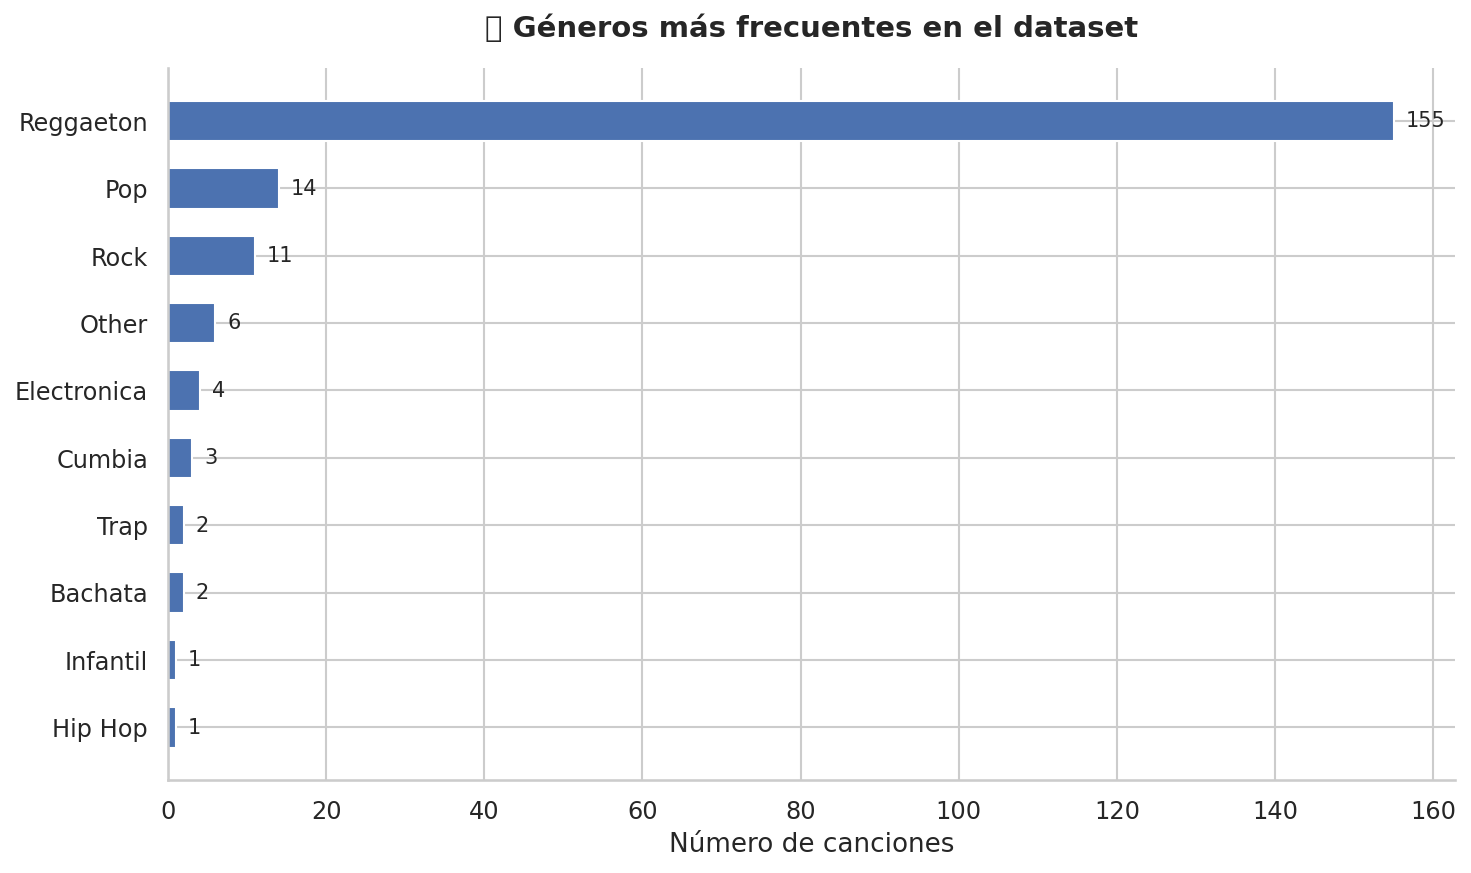

/tmp/ipykernel_154/1469507806.py:123: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


   📊 Guardado: plot_generos_01_conteo.png

── Gráfica 2: Streams totales por género ──


/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


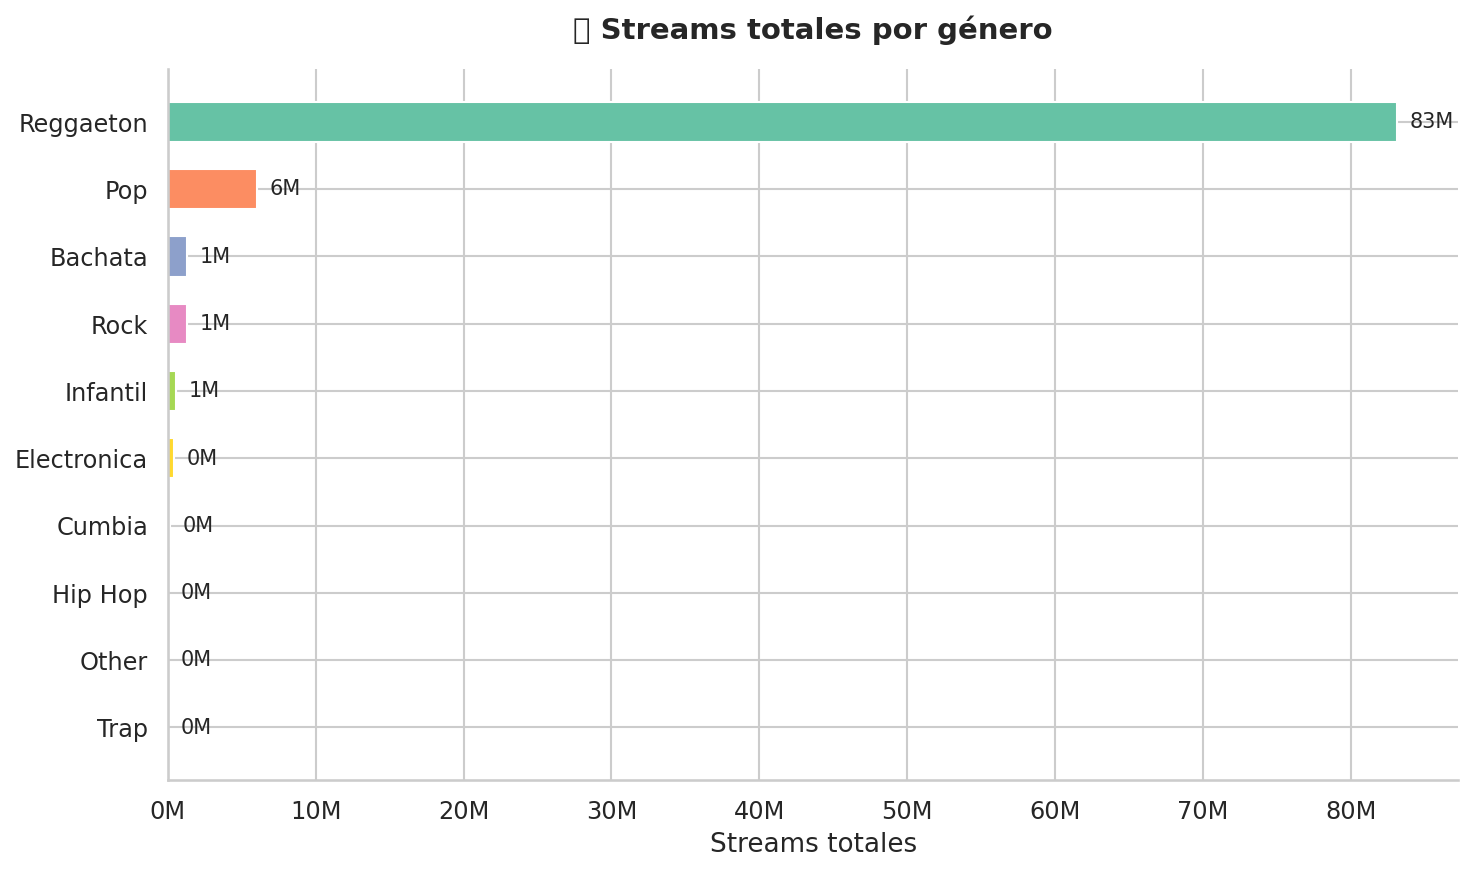

   📊 Guardado: plot_generos_02_streams_totales.png

── Gráfica 3: Proporción de géneros (donut) ──


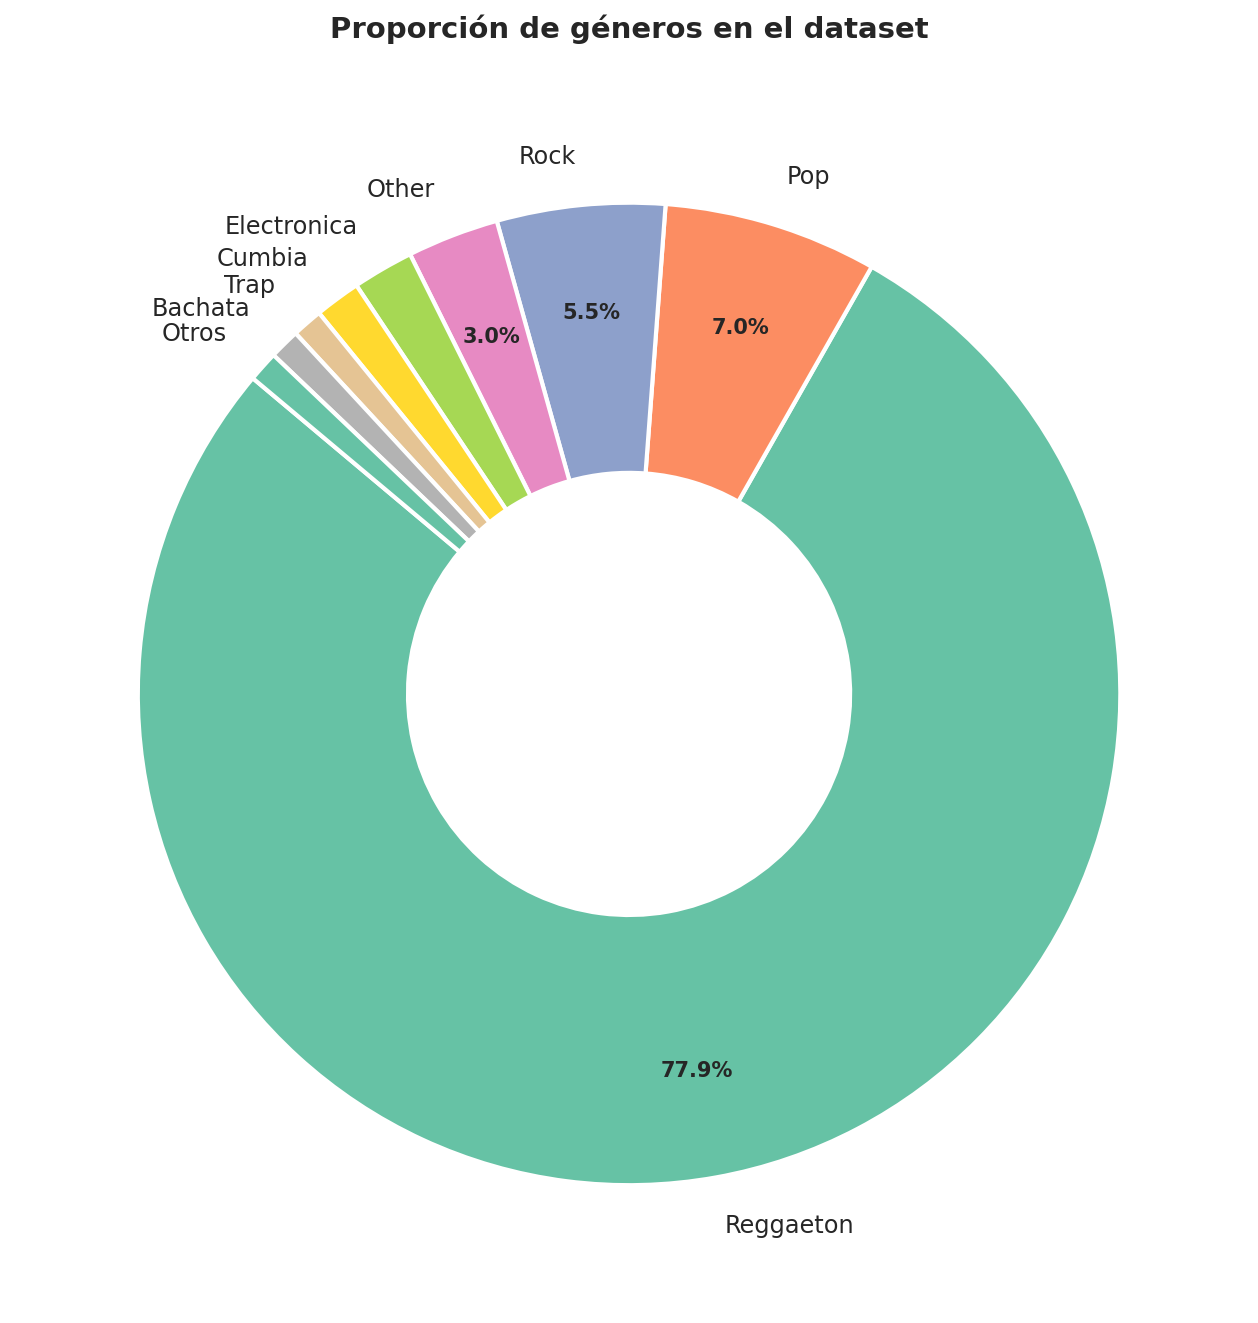

   📊 Guardado: plot_generos_03_donut.png

── Gráfica 4: Streams promedio por género ──


/tmp/ipykernel_154/1469507806.py:189: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


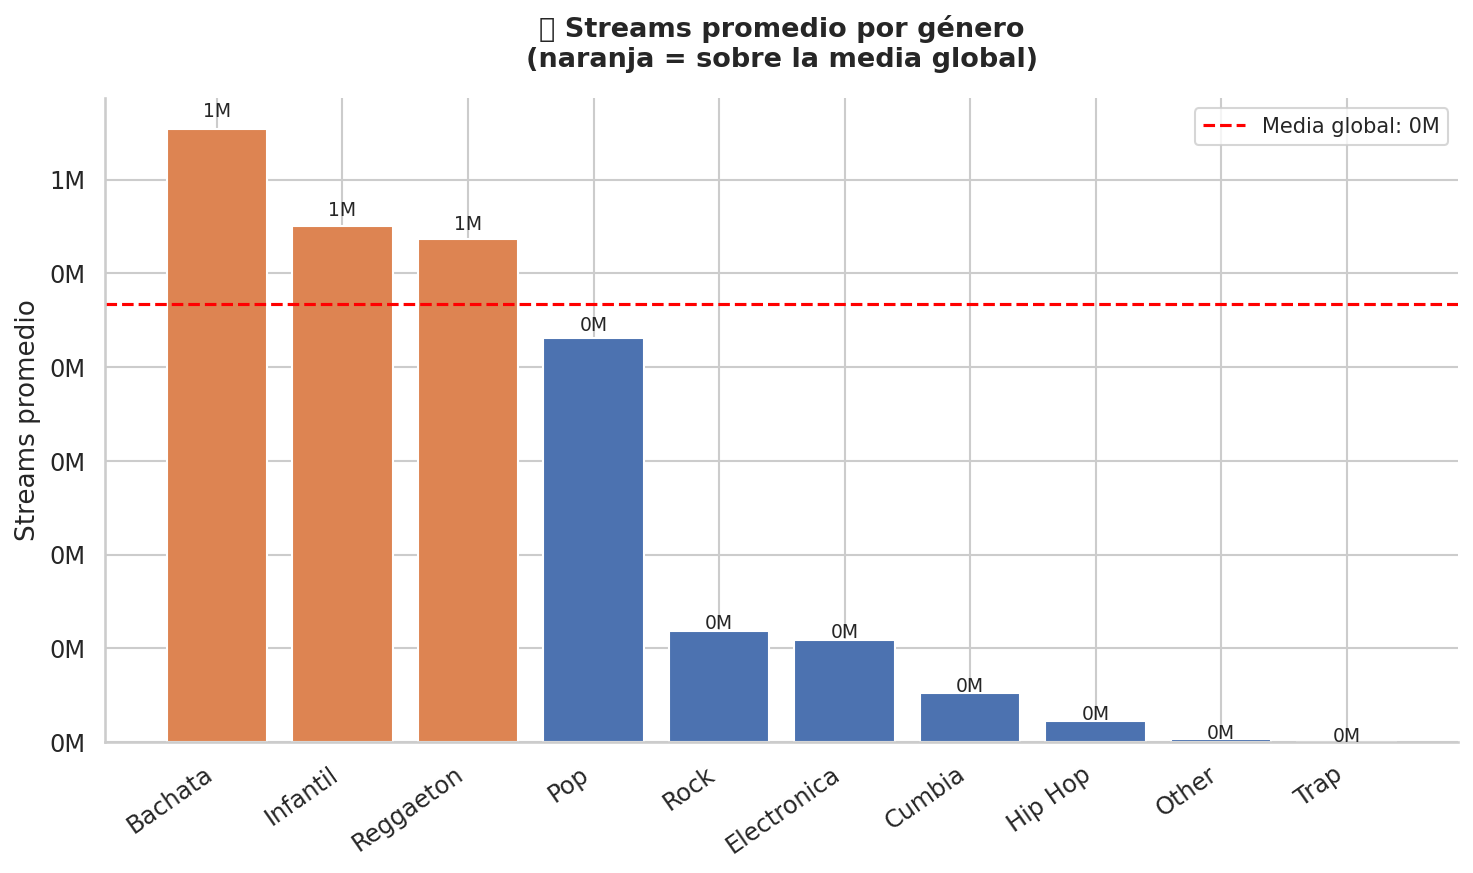

/tmp/ipykernel_154/1469507806.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


   📊 Guardado: plot_generos_04_streams_promedio.png

── Gráfica 5: Distribución de streams por género (boxplot) ──


/tmp/ipykernel_154/1469507806.py:218: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


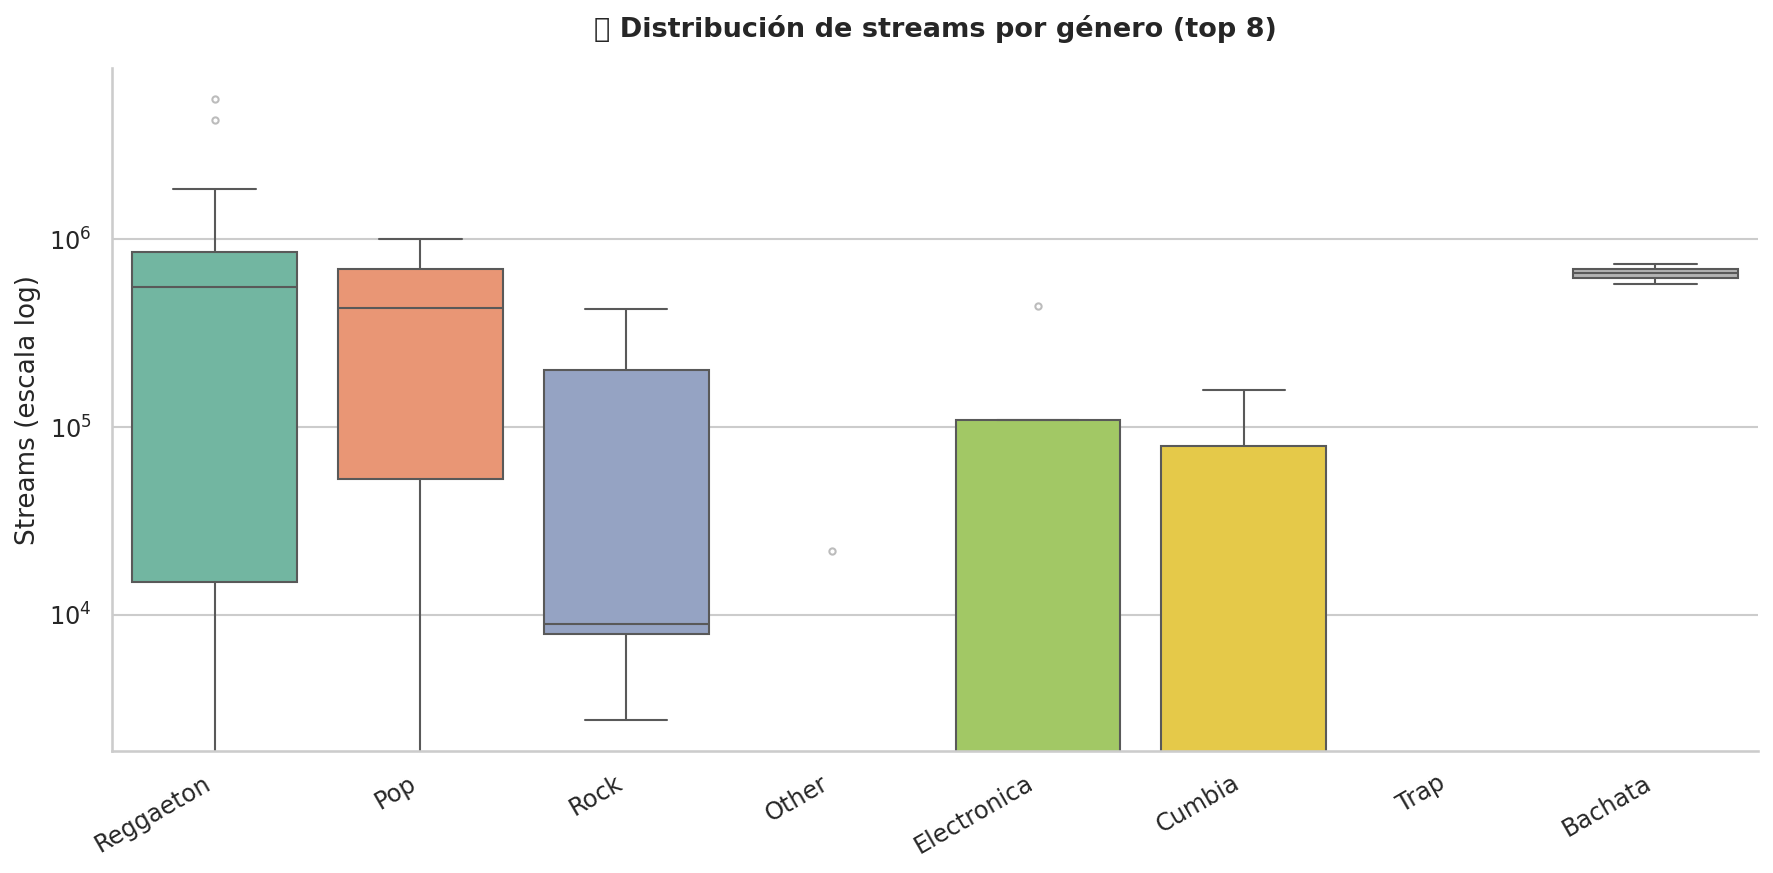

   📊 Guardado: plot_generos_05_boxplot.png

── Gráfica 6: Riqueza léxica (word_count) por género ──


/tmp/ipykernel_154/1469507806.py:248: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


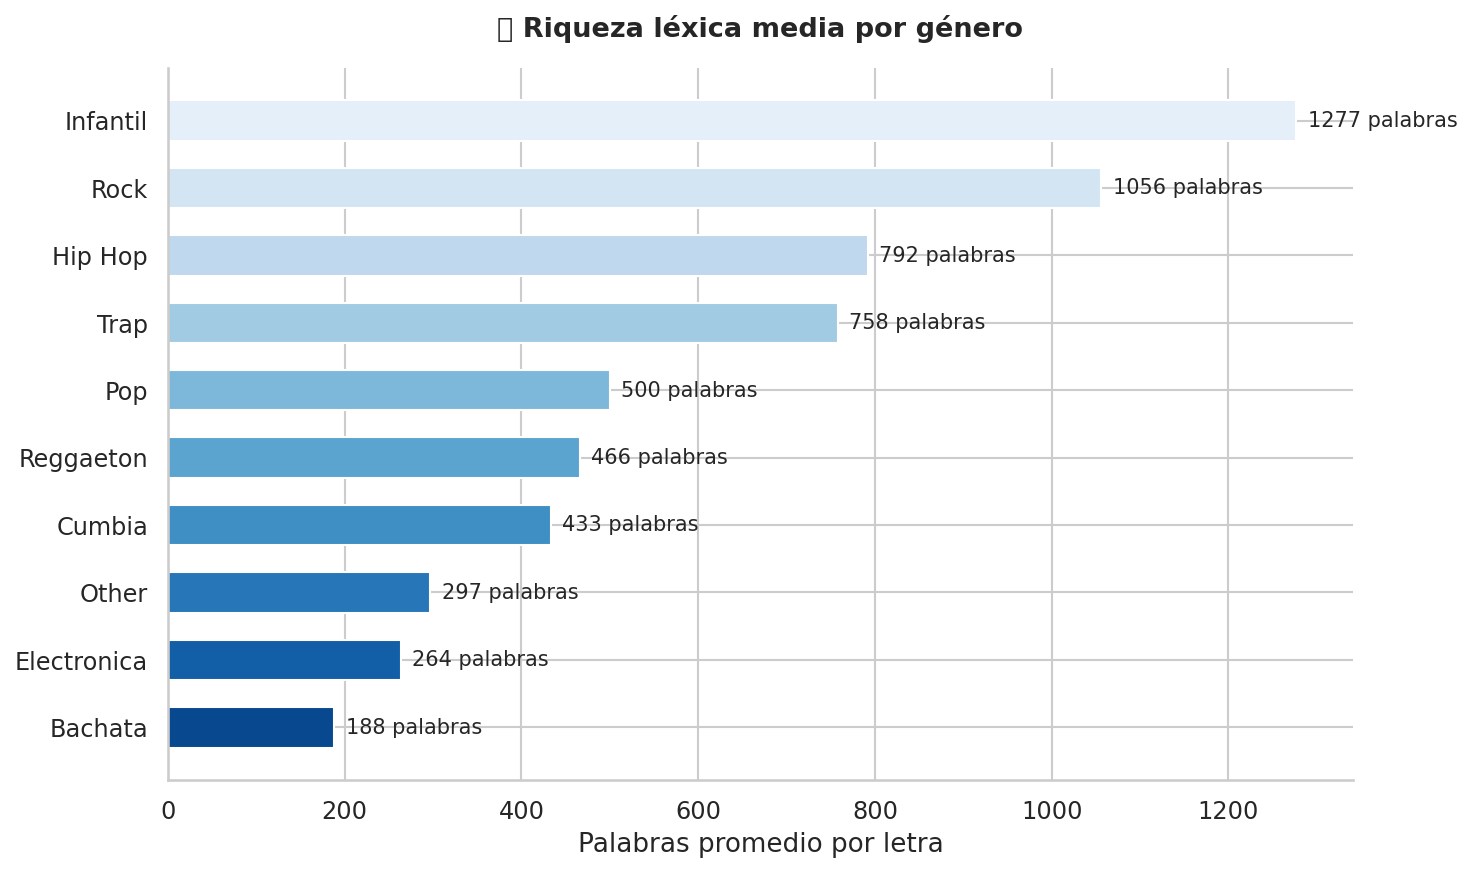

   📊 Guardado: plot_generos_06_lexica.png

── Gráfica 7: Heatmap género vs variante de español ──


/tmp/ipykernel_154/1469507806.py:282: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_154/1469507806.py:67: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


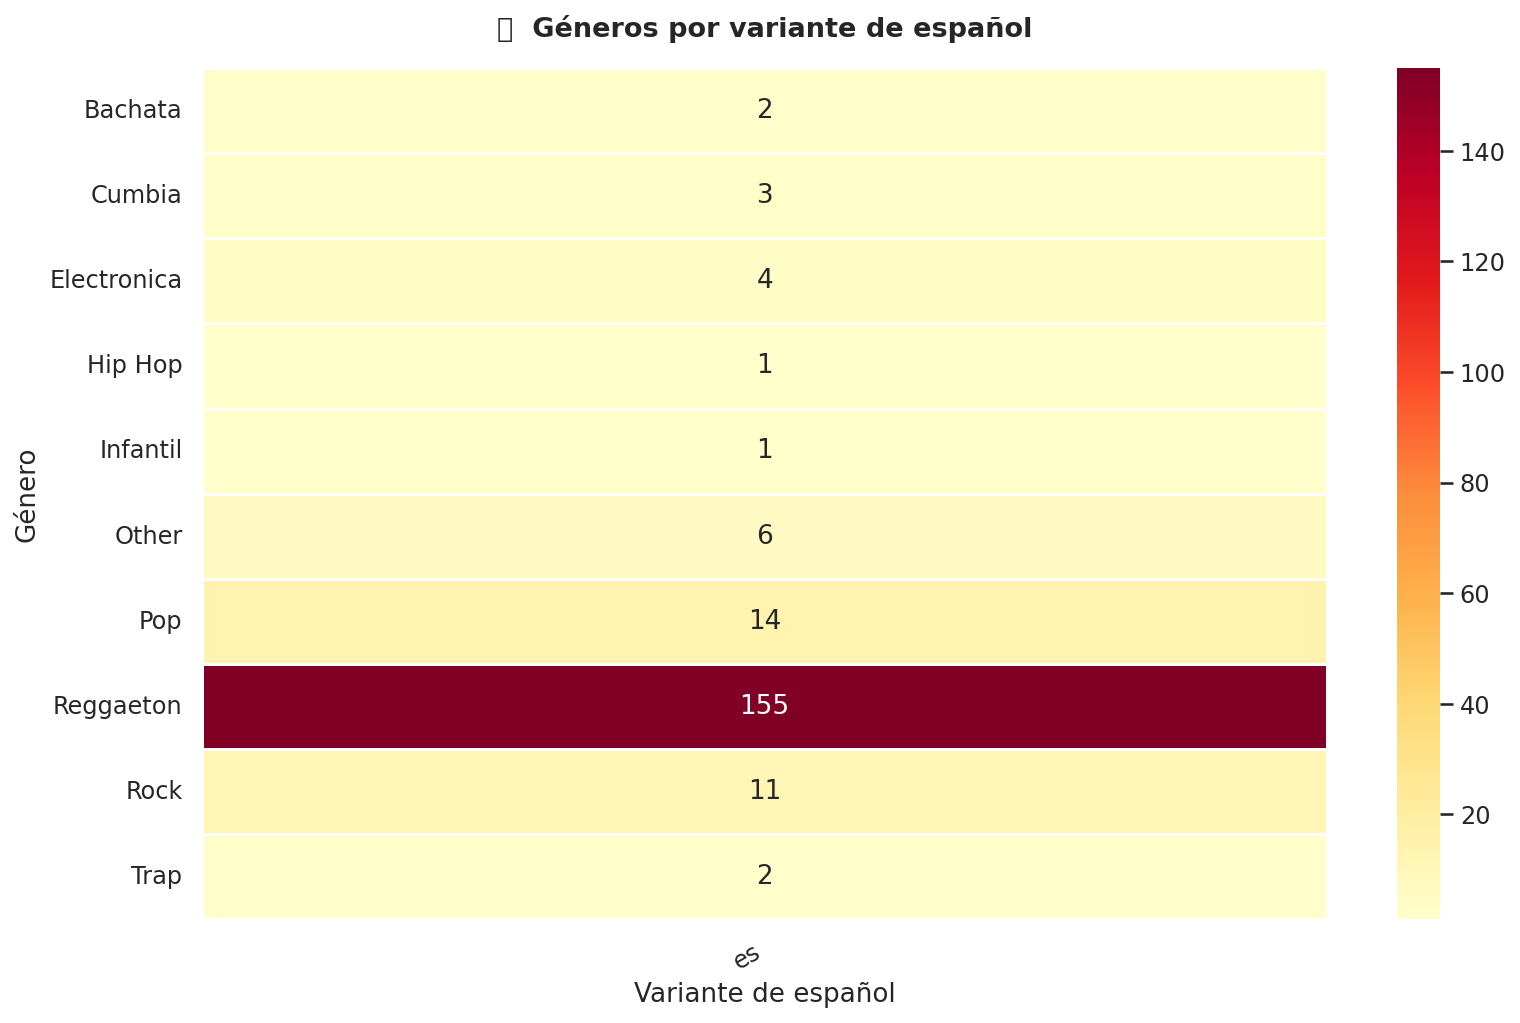

   📊 Guardado: plot_generos_07_heatmap.png

═══════════════════════════════════════════════════════
  RESUMEN — GÉNEROS
═══════════════════════════════════════════════════════
             canciones  streams_total  streams_media  palabras_media
genre                                                               
Reggaeton          155    83115551.00      536229.36          466.17
Pop                 14     6030755.00      430768.21          500.00
Rock                11     1306261.00      118751.00         1056.18
Other                6       21746.00        3624.33          296.83
Electronica          4      436518.00      109129.50          263.75
Cumbia               3      157122.00       52374.00          433.00
Bachata              2     1308936.00      654468.00          188.50
Trap                 2           0.00           0.00          758.50
Infantil             1      550686.00      550686.00         1277.00
Hip Hop              1       23096.00       23096.00          792

In [6]:
"""
EDA — Análisis de géneros musicales más escuchados
====================================================
Datasets de entrada:
  - songs_clean.csv
  - lyrics_clean.csv  (con word_count y verse_count)

Gráficas generadas:
  1. Ranking de géneros por número de canciones (barplot horizontal)
  2. Géneros por streams totales (barplot horizontal)
  3. Proporción de géneros (donut chart)
  4. Streams promedio por género (barplot + línea de media global)
  5. Distribución de streams por género (boxplot)
  6. Géneros por riqueza léxica media (word_count promedio, barplot)
  7. Heatmap: género vs language_variant
  8. Evolución de géneros si hay columna de fecha (lineplot)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ──────────────────────────────────────────────
# CONFIGURACIÓN VISUAL
# ──────────────────────────────────────────────

PALETTE   = "Set2"
COLOR_BAR = "#4C72B0"
COLOR_ACC = "#DD8452"
DPI       = 150

sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": DPI, "axes.spines.top": False, "axes.spines.right": False})

# ──────────────────────────────────────────────
# CARGA
# ──────────────────────────────────────────────

df_songs  = pd.read_csv("songs_clean.csv")
df_lyrics = pd.read_csv("lyrics_clean.csv")

# Merge para cruzar genre con word_count / verse_count
df = pd.merge(df_songs, df_lyrics, left_on="id", right_on="song_id", how="inner")

# Normalizar género
df["genre"] = df["genre"].astype(str).str.strip().str.title()
df_songs["genre"] = df_songs["genre"].astype(str).str.strip().str.title()

# Convertir streams a numérico
if "streams" in df.columns:
    df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

TOP_N = 12   # géneros a mostrar en las gráficas

print(f"✅ Dataset cargado: {len(df)} canciones con letra | {df['genre'].nunique()} géneros únicos\n")
print(df["genre"].value_counts().head(TOP_N).to_string())


# ══════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════

def guardar(nombre):
    plt.savefig(nombre, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"   📊 Guardado: {nombre}")


def top_generos(df, col="genre", n=TOP_N):
    return df[col].value_counts().head(n)


# ══════════════════════════════════════════════
# GRÁFICA 1 — Ranking por número de canciones
# ══════════════════════════════════════════════

print("\n── Gráfica 1: Canciones por género ──")

conteo = top_generos(df)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(conteo.index[::-1], conteo.values[::-1], color=COLOR_BAR, edgecolor="white", height=0.6)
for bar, val in zip(bars, conteo.values[::-1]):
    ax.text(val + conteo.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=10)
ax.set_xlabel("Número de canciones")
ax.set_title("🎵 Géneros más frecuentes en el dataset", fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
guardar("plot_generos_01_conteo.png")


# ══════════════════════════════════════════════
# GRÁFICA 2 — Streams totales por género
# ══════════════════════════════════════════════

if "streams" in df.columns and df["streams"].notna().sum() > 0:
    print("\n── Gráfica 2: Streams totales por género ──")

    streams_totales = (
        df.groupby("genre")["streams"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    colores = sns.color_palette(PALETTE, len(streams_totales))
    bars = ax.barh(streams_totales.index[::-1], streams_totales.values[::-1],
                   color=colores[::-1], edgecolor="white", height=0.6)
    for bar, val in zip(bars, streams_totales.values[::-1]):
        label = f"{val/1e9:.1f}B" if val >= 1e9 else f"{val/1e6:.0f}M"
        ax.text(val + streams_totales.max() * 0.01, bar.get_y() + bar.get_height()/2,
                label, va="center", fontsize=10)
    ax.set_xlabel("Streams totales")
    ax.set_title("🔊 Streams totales por género", fontsize=14, fontweight="bold", pad=15)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e9:.1f}B" if x >= 1e9 else f"{x/1e6:.0f}M"
    ))
    plt.tight_layout()
    guardar("plot_generos_02_streams_totales.png")


# ══════════════════════════════════════════════
# GRÁFICA 3 — Donut chart (proporción de géneros)
# ══════════════════════════════════════════════

print("\n── Gráfica 3: Proporción de géneros (donut) ──")

conteo_donut = top_generos(df, n=8)
otros = len(df) - conteo_donut.sum()
if otros > 0:
    conteo_donut["Otros"] = otros

colores_donut = sns.color_palette(PALETTE, len(conteo_donut))
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    conteo_donut.values,
    labels=conteo_donut.index,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    colors=colores_donut,
    startangle=140,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.78,
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight("bold")
ax.set_title("Proporción de géneros en el dataset", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
guardar("plot_generos_03_donut.png")


# ══════════════════════════════════════════════
# GRÁFICA 4 — Streams promedio por género
# ══════════════════════════════════════════════

if "streams" in df.columns and df["streams"].notna().sum() > 0:
    print("\n── Gráfica 4: Streams promedio por género ──")

    streams_media = (
        df.groupby("genre")["streams"]
        .mean()
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    media_global = df["streams"].mean()

    fig, ax = plt.subplots(figsize=(10, 6))
    colores = [COLOR_ACC if v >= media_global else COLOR_BAR for v in streams_media.values]
    bars = ax.bar(streams_media.index, streams_media.values, color=colores, edgecolor="white")
    ax.axhline(media_global, color="red", linestyle="--", linewidth=1.5,
               label=f"Media global: {media_global/1e6:.0f}M")
    for bar, val in zip(bars, streams_media.values):
        label = f"{val/1e9:.1f}B" if val >= 1e9 else f"{val/1e6:.0f}M"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha="center", fontsize=9)
    ax.set_ylabel("Streams promedio")
    ax.set_title("📈 Streams promedio por género\n(naranja = sobre la media global)",
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e9:.1f}B" if x >= 1e9 else f"{x/1e6:.0f}M"
    ))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    guardar("plot_generos_04_streams_promedio.png")


# ══════════════════════════════════════════════
# GRÁFICA 5 — Boxplot de streams por género
# ══════════════════════════════════════════════

if "streams" in df.columns and df["streams"].notna().sum() > 0:
    print("\n── Gráfica 5: Distribución de streams por género (boxplot) ──")

    top_generos_lista = df["genre"].value_counts().head(8).index.tolist()
    df_box = df[df["genre"].isin(top_generos_lista)].copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(
        data=df_box,
        x="genre", y="streams",
        order=top_generos_lista,
        palette=PALETTE,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
        ax=ax
    )
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel("Streams (escala log)")
    ax.set_title("📦 Distribución de streams por género (top 8)",
                 fontsize=13, fontweight="bold", pad=15)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    guardar("plot_generos_05_boxplot.png")


# ══════════════════════════════════════════════
# GRÁFICA 6 — Riqueza léxica por género
# ══════════════════════════════════════════════

if "word_count" in df.columns:
    print("\n── Gráfica 6: Riqueza léxica (word_count) por género ──")

    df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce")

    lexica = (
        df.groupby("genre")["word_count"]
        .mean()
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    colores = sns.color_palette("Blues_r", len(lexica))
    bars = ax.barh(lexica.index[::-1], lexica.values[::-1],
                   color=colores, edgecolor="white", height=0.6)
    for bar, val in zip(bars, lexica.values[::-1]):
        ax.text(val + lexica.max() * 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.0f} palabras", va="center", fontsize=10)
    ax.set_xlabel("Palabras promedio por letra")
    ax.set_title("📖 Riqueza léxica media por género",
                 fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    guardar("plot_generos_06_lexica.png")


# ══════════════════════════════════════════════
# GRÁFICA 7 — Heatmap género vs language_variant
# ══════════════════════════════════════════════

if "language_variant" in df.columns:
    print("\n── Gráfica 7: Heatmap género vs variante de español ──")

    top_g  = df["genre"].value_counts().head(10).index
    top_lv = df["language_variant"].value_counts().head(8).index
    pivot  = (
        df[df["genre"].isin(top_g) & df["language_variant"].isin(top_lv)]
        .groupby(["genre", "language_variant"])
        .size()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.heatmap(
        pivot,
        annot=True, fmt="d",
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )
    ax.set_title("🗺️  Géneros por variante de español",
                 fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Variante de español")
    ax.set_ylabel("Género")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    guardar("plot_generos_07_heatmap.png")


# ══════════════════════════════════════════════
# GRÁFICA 8 — Evolución temporal (si hay fecha)
# ══════════════════════════════════════════════

fecha_col = next((c for c in df.columns if "created_at" in c and "song" in c), None)
if fecha_col:
    print("\n── Gráfica 8: Evolución de géneros en el tiempo ──")

    df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")
    df["mes"] = df[fecha_col].dt.to_period("M")

    top5 = df["genre"].value_counts().head(5).index.tolist()
    evolucion = (
        df[df["genre"].isin(top5)]
        .groupby(["mes", "genre"])
        .size()
        .reset_index(name="canciones")
    )
    evolucion["mes"] = evolucion["mes"].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(13, 6))
    for genero, color in zip(top5, sns.color_palette(PALETTE, 5)):
        datos = evolucion[evolucion["genre"] == genero]
        ax.plot(datos["mes"], datos["canciones"], marker="o", label=genero,
                color=color, linewidth=2, markersize=5)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Canciones nuevas")
    ax.set_title("📅 Evolución mensual de los 5 géneros principales",
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(title="Género", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    guardar("plot_generos_08_evolucion.png")


# ══════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════

print("\n" + "═"*55)
print("  RESUMEN — GÉNEROS")
print("═"*55)

# Detectar columna id disponible tras el merge
id_col = next((c for c in ["id_song", "id_x", "id"] if c in df.columns), df.columns[0])

agg_dict = {"canciones": (id_col, "count")}
if "streams"    in df.columns: agg_dict["streams_total"]  = ("streams",    "sum")
if "streams"    in df.columns: agg_dict["streams_media"]  = ("streams",    "mean")
if "word_count" in df.columns: agg_dict["palabras_media"] = ("word_count", "mean")

resumen = (
    df.groupby("genre")
    .agg(**agg_dict)
    .sort_values("canciones", ascending=False)
    .head(TOP_N)
)

print(resumen.to_string())
print("\n📁 Gráficas generadas:")
for f in sorted(Path(".").glob("plot_generos_*.png")):
    print(f"   ✔ {f.name}")

# Conclusiones

El dataset construido a partir del scraping de letras.com refleja con precisión el ecosistema musical hispanohablante actual, compuesto por 200 canciones en español publicadas entre 2023 y 2026, distribuidas en 10 géneros y almacenadas en Supabase tras pasar un pipeline de validación estricto por año, idioma y deduplicación.<br/><br/>
**El reggaeton es el género hegemónico**, representando el 77,5% de las canciones y el 91,8% de los streams totales (83,1M sobre 91M). No solo lidera en volumen de producción, sino también en engagement por oyente, lo que confirma su posición como el género central del mercado hispanohablante en este periodo.<br/><br/>
**La bachata destaca como el género más eficiente por canción**, con 654.468 streams de media con solo 2 canciones en el dataset, superando incluso al reggaeton (536.229). Esto sugiere un alto potencial viral, aunque la muestra es demasiado pequeña para ser concluyente, por lo que ampliar este género en futuras recopilaciones es prioritario.<br/><br/>
**Se confirma una correlación negativa entre streams y riqueza léxica:** el rock lidera en vocabulario (1.056 palabras de media) pero queda muy por debajo en streams, mientras que el reggaeton y la electrónica, con letras más cortas y repetitivas (466 y 264 palabras respectivamente), concentran el mayor consumo. Esto tiene implicaciones directas para cualquier modelo de NLP que se entrene sobre estas letras.<br/><br/>
**El proceso de limpieza fue determinante:** el pipeline aplicado en dos fases (filtro por año vía MusicBrainz + filtro por idioma vía langdetect) garantiza que todas las letras del dataset final son en español y de los últimos 3 años. Adicionalmente, la deduplicación por lyrics_hash y song_id eliminó letras idénticas y canciones con múltiples entradas, asegurando la integridad del dataset.<br/><br/>
**El principal riesgo del dataset es su desequilibrio:** el 77% de los datos pertenece a un único género. Si se entrena un modelo de ML sobre él en su estado actual, existirá un sesgo severo hacia el reggaeton. Se recomienda aplicar técnicas de balanceo (oversampling de géneros minoritarios, undersampling del reggaeton, o pesos por clase) antes de cualquier entrenamiento, o bien ampliar el scraping de géneros con menos de 5 canciones (Electrónica, Cumbia, Bachata, Trap, Hip Hop, Infantil) hasta alcanzar una distribución más equilibrada.